[Link da apresentação](https://youtu.be/)

## 1. Previsão de pagamento de empréstimos


In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier


In [314]:
comparativo = {}

In [315]:
headers = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']
data = pd.read_csv('data/credtrain.txt', sep='\t', names=headers)
test_data = pd.read_csv('data/credtest.txt', sep='\t', names=headers)

data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')
test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')

data.head(10)

,ESCT,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,CLASSE
0,1,0,360,0,313,9,52,0,25,48,0,1
1,0,0,350,1,468,10,65,0,33,6,0,1
2,0,0,1100,0,829,9,125,0,56,48,0,1
3,0,0,3000,0,552,12,76,1,31,60,0,1
4,1,0,1000,0,809,12,111,0,24,7,0,1
5,0,0,300,0,331,6,74,1,41,0,0,1
6,0,2,580,1,349,10,51,0,30,6,0,0
7,0,0,300,0,416,10,64,0,48,108,0,1
8,0,0,1500,0,688,6,148,0,59,48,0,0
9,0,1,500,1,828,18,89,0,29,6,0,1


In [316]:
categorical_ordinal = ['NDEP']
categorical_one_hot = ['ESCT', 'TIPOR', 'TEL']
continuous_features = ['RENDA', 'VBEM', 'NPARC', 'VPARC', 'IDADE', 'RESMS', 'ENTRADA']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), continuous_features),
    ('one', OneHotEncoder(drop='first'), categorical_one_hot),
    ('ord', OrdinalEncoder(), categorical_ordinal)
])

X_processed = preprocessor.fit_transform(data)

# Get column names
num_feature_names = continuous_features
cat_feature_names = preprocessor.named_transformers_['one'].get_feature_names_out(categorical_one_hot).tolist()
ordinal_feature_names = categorical_ordinal  # OrdinalEncoder keeps the original name

final_feature_names = num_feature_names + cat_feature_names + ordinal_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

X_processed_df.head()

,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA,ESCT_1,ESCT_2,ESCT_3,TIPOR_1,TEL_1,NDEP
0,-0.689892,-0.937611,0.168333,-0.798003,-1.228280,0.312878,-0.342137,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.700939,-0.354031,0.445500,-0.591544,-0.622121,-0.484925,-0.342137,0.0,0.0,0.0,1.0,0.0,0.0
2,0.127578,1.005145,0.168333,0.361347,1.120585,0.312878,-0.342137,0.0,0.0,0.0,0.0,0.0,0.0
3,2.226490,-0.037768,0.999835,-0.416847,-0.773661,0.540822,-0.342137,0.0,0.0,0.0,0.0,1.0,0.0
4,0.017109,0.929845,0.999835,0.139006,-1.304049,-0.465930,-0.342137,1.0,0.0,0.0,0.0,0.0,0.0


In [317]:
x = X_processed_df
y = data['CLASSE']

In [318]:
# Criar modelos
models_1 = {
    "Logistic Regression": LogisticRegression,
    "KNN": KNeighborsClassifier,
    "XGBoost": XGBClassifier,
}

for model_name, model in models_1.items():
    models_1[model_name] = Pipeline([
        ('classifier', model())
    ])

# Treinar modelos
for model_name, model in models_1.items():
    model.fit(x, y)


In [319]:
# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Logistic Regression:
[[292  14]
 [ 50 221]]


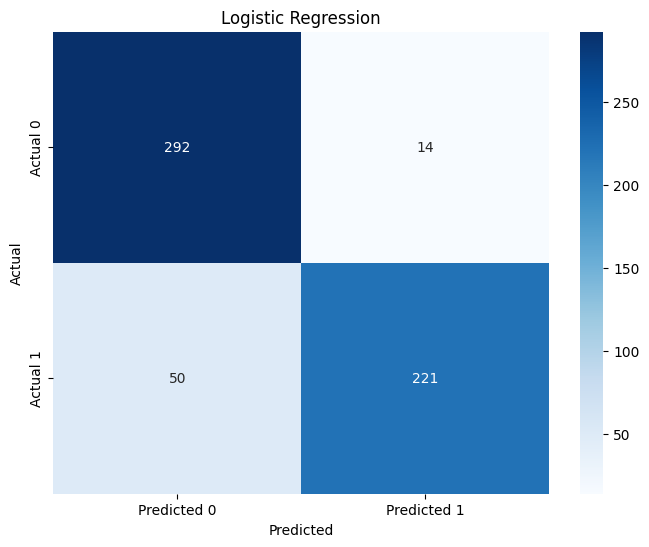

KNN:
[[277  29]
 [ 58 213]]


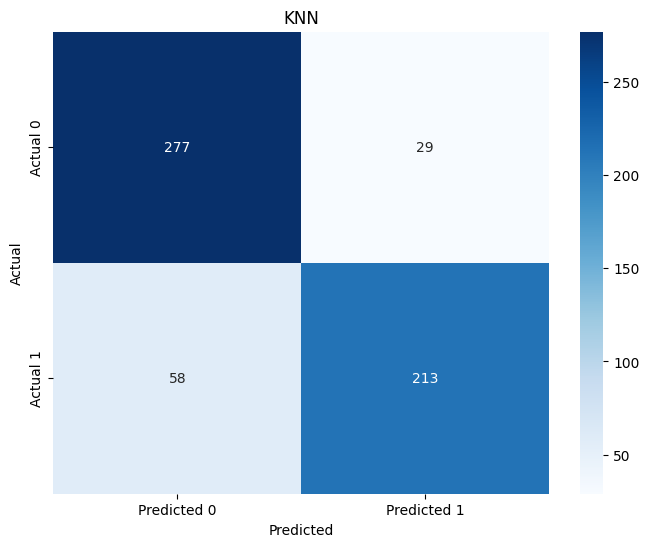

XGBoost:
[[289  17]
 [ 45 226]]


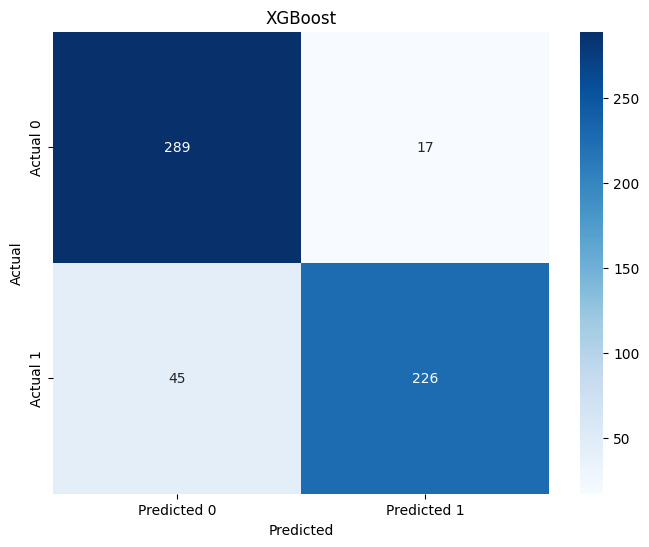

{'Logistic Regression_1': 0.8890814558058926,
 'KNN_1': 0.8492201039861352,
 'XGBoost_1': 0.8925476603119584}

In [320]:
X_test_processed = preprocessor.fit_transform(test_data)

y_test = test_data['CLASSE']
X_test_processed_df = pd.DataFrame(X_test_processed, columns=final_feature_names)


# Criar modelos e fazer previsões
y_preds = {}
for model_name, model in models_1.items():
    y_preds[model_name] = model.predict(X_test_processed_df)

for model_name, y_pred in y_preds.items():
    print(f"{model_name}:")
    print(confusion_matrix(y_test, y_pred))
    plot_confusion_matrix(y_test, y_pred, model_name)
    report = classification_report(y_test, y_pred, output_dict=True)
    comparativo[f"{model_name}_1"] = report['accuracy']

comparativo


## 2. Engenharia de Features

In [321]:
from category_encoders import OrdinalEncoder, GrayEncoder, CountEncoder

models_2 = {
    "Logistic Regression": LogisticRegression,
    "KNN": KNeighborsClassifier,
    "XGBoost": XGBClassifier,
}

In [322]:
# Carregar os dados de treino e teste
headers = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']
data = pd.read_csv('data/credtrain.txt', sep='\t', names=headers)
test_data = pd.read_csv('data/credtest.txt', sep='\t', names=headers)

data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')
test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']] = test_data[['ESCT', 'NDEP', 'TIPOR', 'TEL', 'CLASSE']].astype('category')

In [323]:
# Definir variáveis categóricas e contínuas
count_cat_col = ['ESCT']
ordinal_cat_col = ['NDEP']
one_hot_cat_col = ['TIPOR', 'TEL']
standard_num_col = ['RENDA', 'VBEM', 'NPARC', 'VPARC', 'IDADE', 'RESMS', 'ENTRADA']


preprocessor = ColumnTransformer([
        ('count', CountEncoder(normalize=True), count_cat_col),
        ('gray', GrayEncoder(), ordinal_cat_col),
        ('one_hot', OneHotEncoder(drop='first'), one_hot_cat_col),
        ('scaler', StandardScaler(), standard_num_col),
    ])

X_processed = preprocessor.fit_transform(data)

# Update final_feature_names to include the correct number of columns
cat_feature_names = preprocessor.named_transformers_['one_hot'].get_feature_names_out(one_hot_cat_col).tolist()
ordinal_feature_names = preprocessor.named_transformers_['gray'].get_feature_names_out(ordinal_cat_col).tolist()
count_feature_names = preprocessor.named_transformers_['count'].get_feature_names_out(count_cat_col).tolist()
num_feature_names = standard_num_col

final_feature_names = count_feature_names + ordinal_feature_names + cat_feature_names + num_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

# Show the first few rows
X_processed_df.head()

,ESCT,NDEP_0,NDEP_1,NDEP_2,NDEP_3,TIPOR_1,TEL_1,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA
0,0.400667,0.0,0.0,0.0,1.0,0.0,0.0,-0.689892,-0.937611,0.168333,-0.798003,-1.228280,0.312878,-0.342137
1,0.556000,0.0,0.0,0.0,1.0,1.0,0.0,-0.700939,-0.354031,0.445500,-0.591544,-0.622121,-0.484925,-0.342137
2,0.556000,0.0,0.0,0.0,1.0,0.0,0.0,0.127578,1.005145,0.168333,0.361347,1.120585,0.312878,-0.342137
3,0.556000,0.0,0.0,0.0,1.0,0.0,1.0,2.226490,-0.037768,0.999835,-0.416847,-0.773661,0.540822,-0.342137
4,0.400667,0.0,0.0,0.0,1.0,0.0,0.0,0.017109,0.929845,0.999835,0.139006,-1.304049,-0.465930,-0.342137


In [324]:
X = X_processed_df
y = data["CLASSE"]

In [325]:
X_test_processed = preprocessor.transform(test_data)

y_test = test_data['CLASSE']
X_test_processed_df = pd.DataFrame(X_test_processed, columns=final_feature_names)

[[288  18]
 [ 46 225]]


d:\Estudos\BCC\Inteligencia Artifical\Trabalho 4\Codigo\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


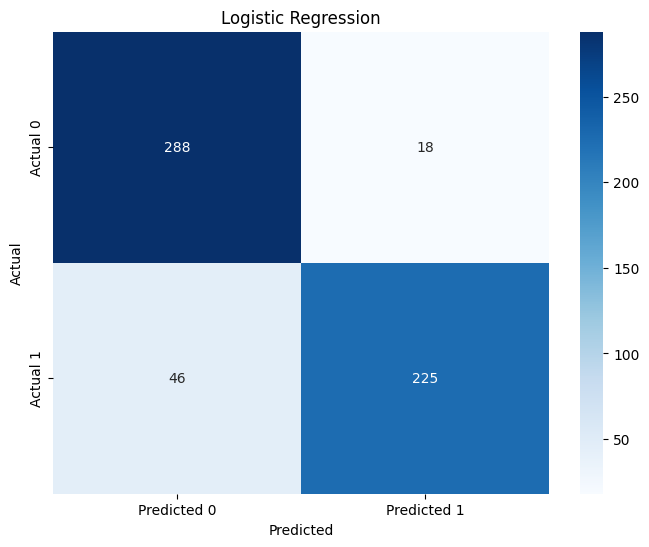

[[275  31]
 [ 52 219]]


d:\Estudos\BCC\Inteligencia Artifical\Trabalho 4\Codigo\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


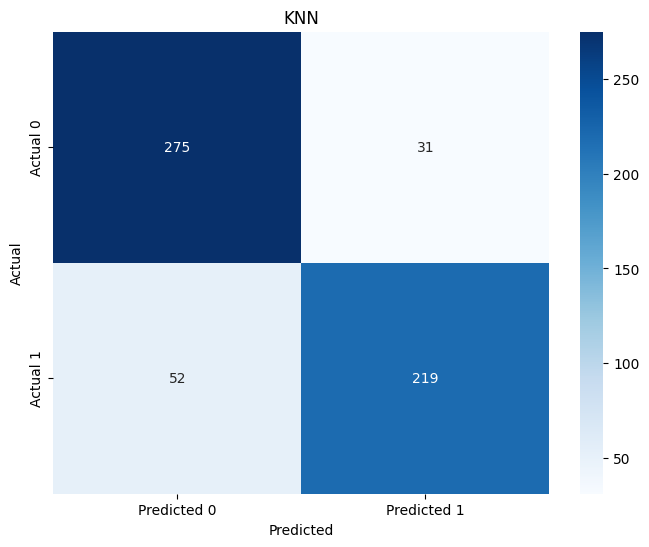

[[280  26]
 [ 42 229]]


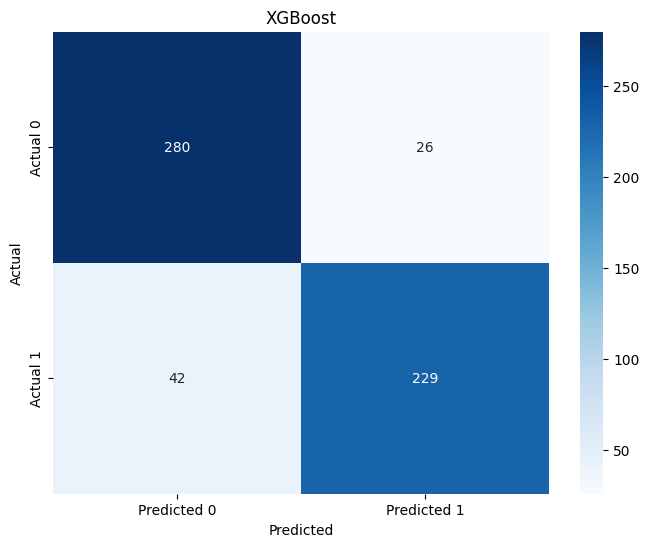

In [326]:
# Testar cada modelo com os dados transformados
for model_name, model in models_1.items():
    model.fit(X, y)
    y_pred = model.predict(X_test_processed)
    print(confusion_matrix(y_test, y_pred))
    plot_confusion_matrix(y_test, y_pred, model_name)
    report = classification_report(y_test, y_pred, output_dict=True)
    comparativo[f"{model_name}_2"] = report['accuracy']

In [327]:
pd.DataFrame.from_dict(comparativo, orient='index', columns=['Accuracy']).transpose()


,Logistic Regression_1,KNN_1,XGBoost_1,Logistic Regression_2,KNN_2,XGBoost_2
Accuracy,0.889081,0.84922,0.892548,0.889081,0.856153,0.882149


## 3. Conjuntos desbalanceados - parte I

In [328]:
# Load the .npy files
X_train = np.load('data/falldetection/X_train.npy')
y_train = np.load('data/falldetection/y_train.npy')
X_val = np.load('data/falldetection/X_val.npy')
y_val = np.load('data/falldetection/y_val.npy')
X_test = np.load('data/falldetection/X_test.npy')
y_test = np.load('data/falldetection/y_test.npy')

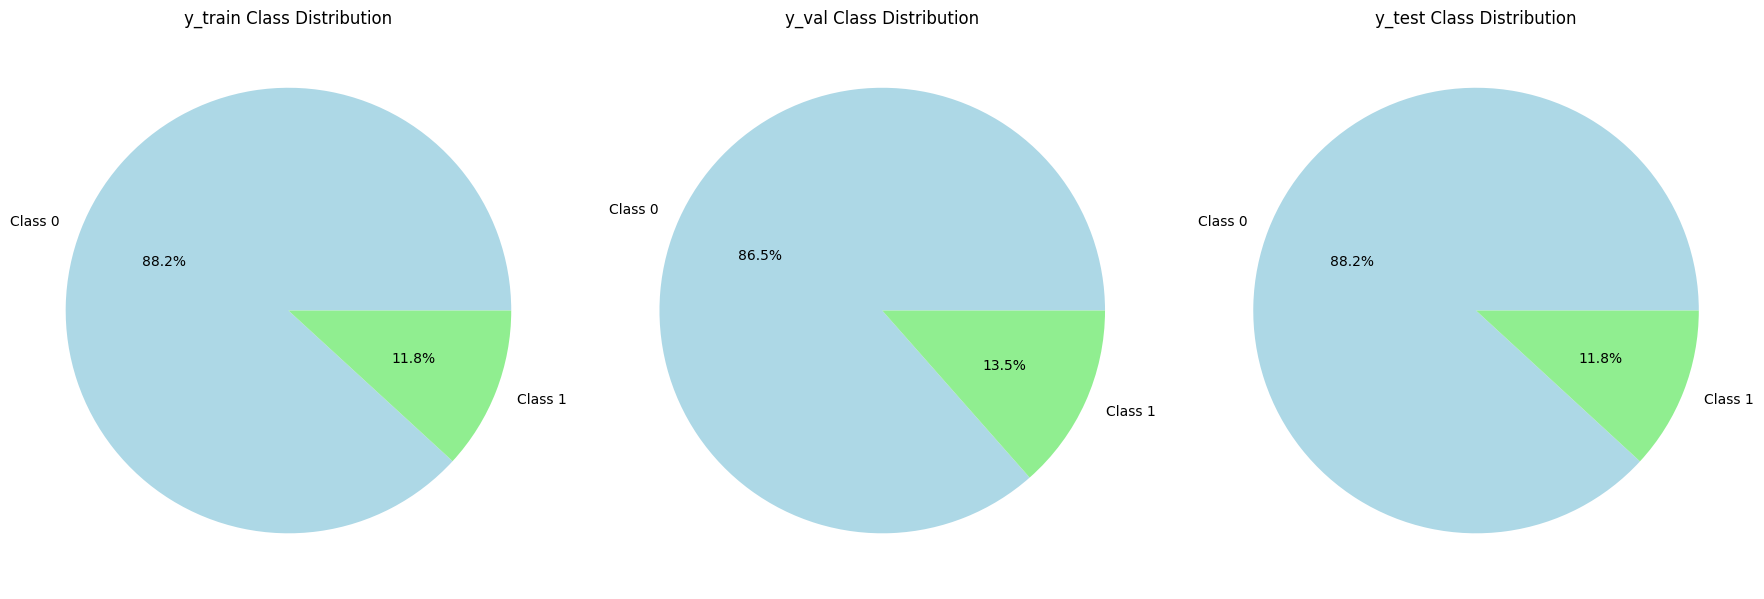

In [329]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# y_train distribution
train_counts = np.bincount(y_train)
axes[0].pie(train_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[0].set_title('y_train Class Distribution')

# y_val distribution
val_counts = np.bincount(y_val)
axes[1].pie(val_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[1].set_title('y_val Class Distribution')

# y_test distribution
test_counts = np.bincount(y_test)
axes[2].pie(test_counts, labels=['Class 0', 'Class 1'], autopct='%1.1f%%', colors=['lightblue', 'lightgreen'])
axes[2].set_title('y_test Class Distribution')

plt.tight_layout()
plt.show()